# Figures of the Model F145F2, Thesis model. 

## Used libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Seaborn configuration:

In [2]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
    "figure.dpi": 300,           # Default DPI for new figures
    "savefig.dpi": 300,          # DPI when saving figures

    # Font settings
    "font.family": "sans-serif",     # Universal font family
    "font.size": 11,                   # Base font size

    # Title and label sizes
    "axes.titlesize": 16,             # Axis title size
    "axes.titleweight": "bold",       # Axis title weight
    "axes.labelsize": 14,             # Axis label size
    "axes.labelweight": "semibold",   # Axis label weight

    # -------------------------------------------------

    # Tick LABEL sizes (text next to ticks)
    "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
    "ytick.labelsize": 11,       # Size of y-axis tick labels

    # Tick MARK sizes (physical marks on axes)
    "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
    "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

    # Additional tick parameters you might want to use:
    "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
    "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

    # Tick WIDTH (thickness)
    "xtick.major.width": 1,      # Width/Thickness of major ticks
    "ytick.major.width": 1,      # Width/Thickness of major ticks

    # Tick PADDING (distance from label to tick)
    "xtick.major.pad": 3.5,      # Padding between x-tick and label
    "ytick.major.pad": 3.5,      # Padding between y-tick and label

    # Tick DIRECTIONS
    "xtick.direction": "out",    # "in", "out", or "inout"
    "ytick.direction": "out",    # Points outward from axis

    # Tick COLORS
    "xtick.color": "black",      # Color of x-axis ticks and labels
    "ytick.color": "black",      # Color of y-axis ticks and labels

    # MINOR ticks (for more granular scales)
    "xtick.minor.visible": False,  # Show minor x-ticks
    "ytick.minor.visible": False,  # Show minor y-ticks

    # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
    "xtick.top": False,          # Show ticks on top of plot
    "xtick.bottom": True,        # Show ticks on bottom (default: True)
    "ytick.left": True,          # Show ticks on left (default: True)
    "ytick.right": False,        # Show ticks on right

    # ---------------------------------

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,
    "legend.framealpha":0.9,

    # Figure title (for suptitle)
    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    # ----------------------------------

    # Figure border
    #"figure.edgecolor": "black",
    #"figure.frameon": True,
    #"figure.linewidth": 2.0,

    # Axes borders (spines)
    "axes.linewidth": 1.0,           # Width of axis lines
    "axes.edgecolor": "black",       # Color of axis lines

    # Individual spine control via rcParams
    "axes.spines.top": True,
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,

    # ----------------------------
    # Patch properties (for histograms, bars, kde fills, etc.)
    "patch.linewidth": 1.5,           # Default linewidth for patches
    "patch.edgecolor": "black",       # Default edge color
    "patch.facecolor": "blue",        # Default fill color (careful with this!)
    "patch.force_edgecolor": True,    # Always show edges

    "axes.grid": False,           # Turn off grid completely

})

## Path to Data

In [3]:
path  = './models/UNET-F145F2/training.log'

## Read the data

In [4]:
data = pd.read_csv(path)
data

,epoch,loss,lr,mape,root_mean_squared_error,val_loss,val_mape,val_root_mean_squared_error
0,0,226.339554,0.001,33.197384,407.680878,13.959062,4.584838,28.912682
1,1,31.856064,0.001,9.187705,45.015701,19.124950,7.134892,34.763939
2,2,28.747463,0.001,8.228964,38.021835,89.788315,12.594267,109.108505
3,3,27.412048,0.001,7.720563,36.000664,60.054432,10.163095,72.234245
4,4,26.433949,0.001,7.469689,34.822536,18.400415,4.454831,23.568861
...,...,...,...,...,...,...,...,...
95,95,20.936871,0.001,5.584755,27.236126,8.079728,1.721159,10.071419
96,96,20.882559,0.001,5.587729,27.159967,101.237190,10.747716,135.236130
97,97,20.838703,0.001,5.564320,27.099403,9.709145,1.813720,15.933248
98,98,21.023106,0.001,5.621871,27.368879,49.872025,5.685211,76.206360


## MAE

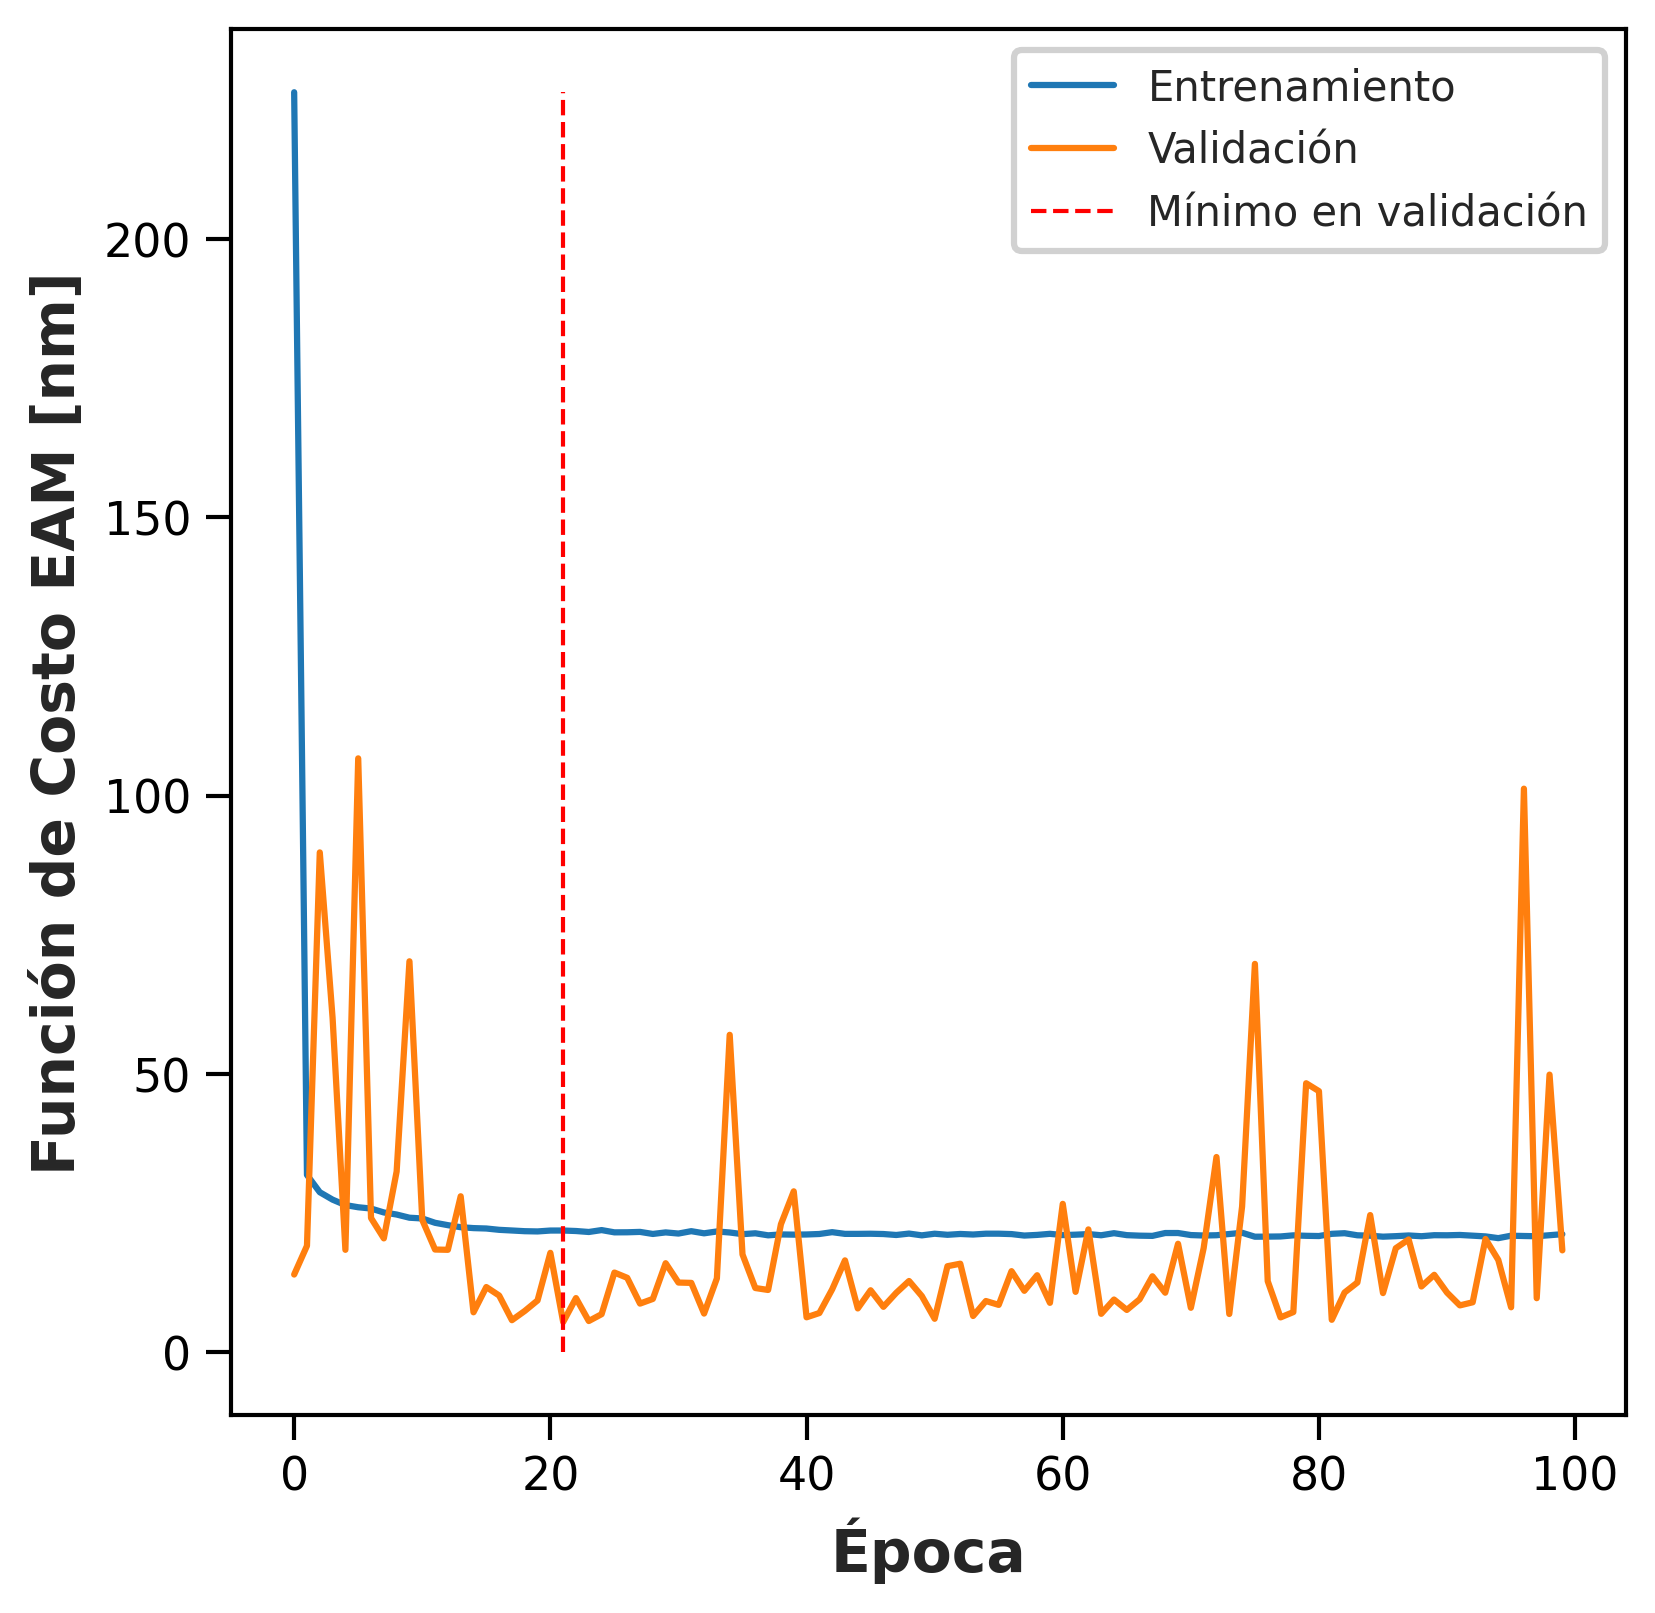

In [5]:
plt.figure(figsize = (6,6))
plt.plot(data['epoch'], data['loss'], label = 'Entrenamiento')
plt.plot(data['epoch'], data['val_loss'], label = 'Validación')
plt.vlines( 
    np.argmin(data['val_loss']), 
    0, 
    np.max(data['loss']), 
    linestyles= '--', 
    color = 'red', 
    lw = 1, 
    label = 'Mínimo en validación'
)
plt.xlabel('Época')
plt.ylabel('Función de Costo EAM [nm]')
plt.legend()
plt.savefig('./images/mae.png')
plt.show()

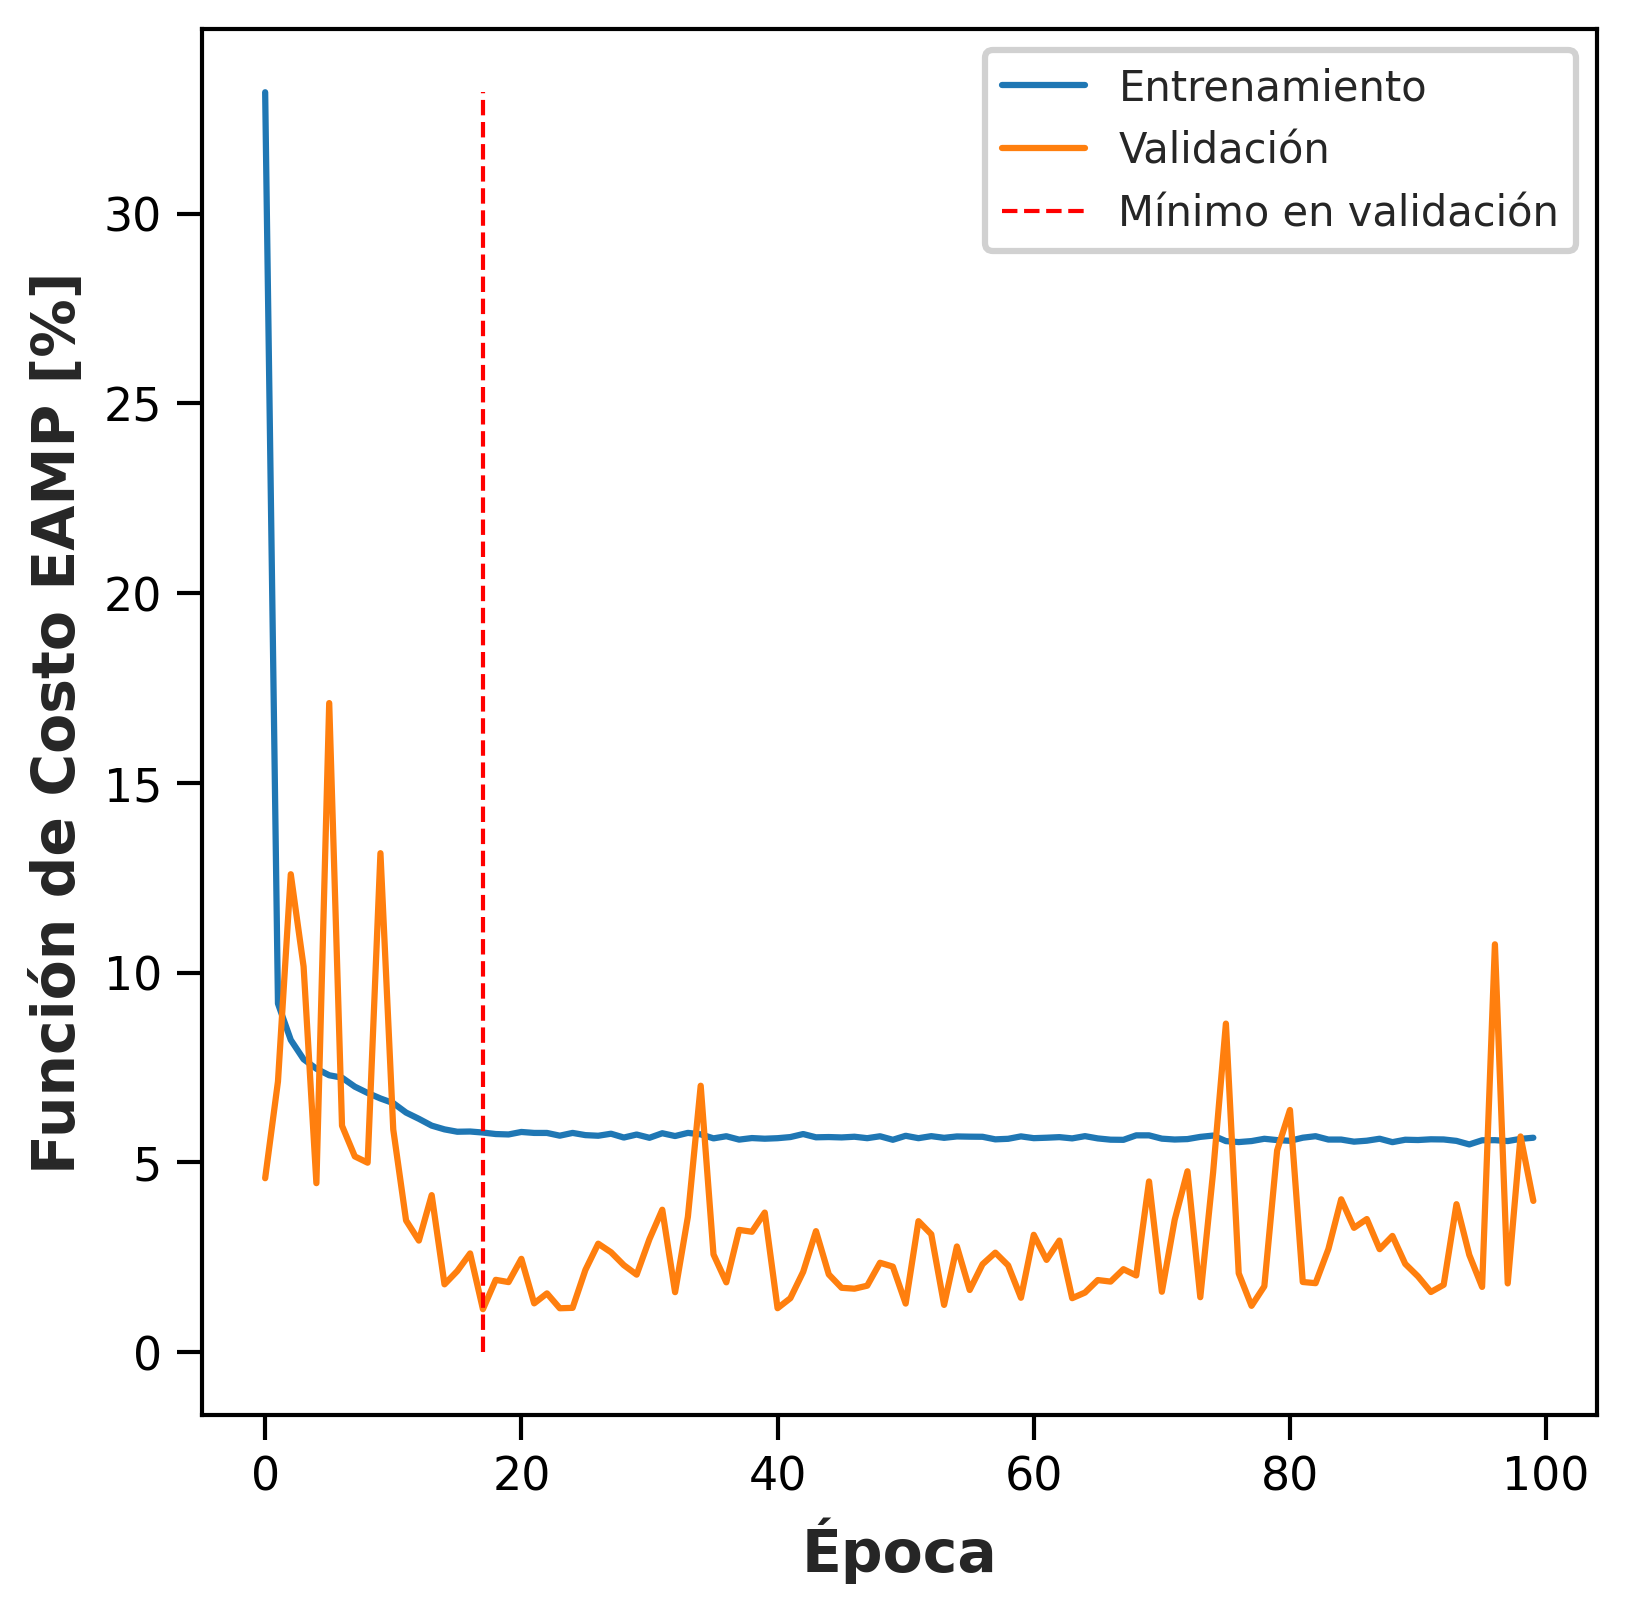

In [6]:
plt.figure(figsize = (6,6))
plt.plot(data['epoch'], data['mape'], label = 'Entrenamiento')
plt.plot(data['epoch'], data['val_mape'], label = 'Validación')
plt.vlines( 
    np.argmin(data['val_mape']), 
    0, 
    np.max(data['mape']), 
    linestyles= '--', 
    color = 'red', 
    lw = 1, 
    label = 'Mínimo en validación'
)
plt.xlabel('Época')
plt.ylabel('Función de Costo EAMP [%]')
plt.legend()
plt.savefig('./images/mape.png')
plt.show()

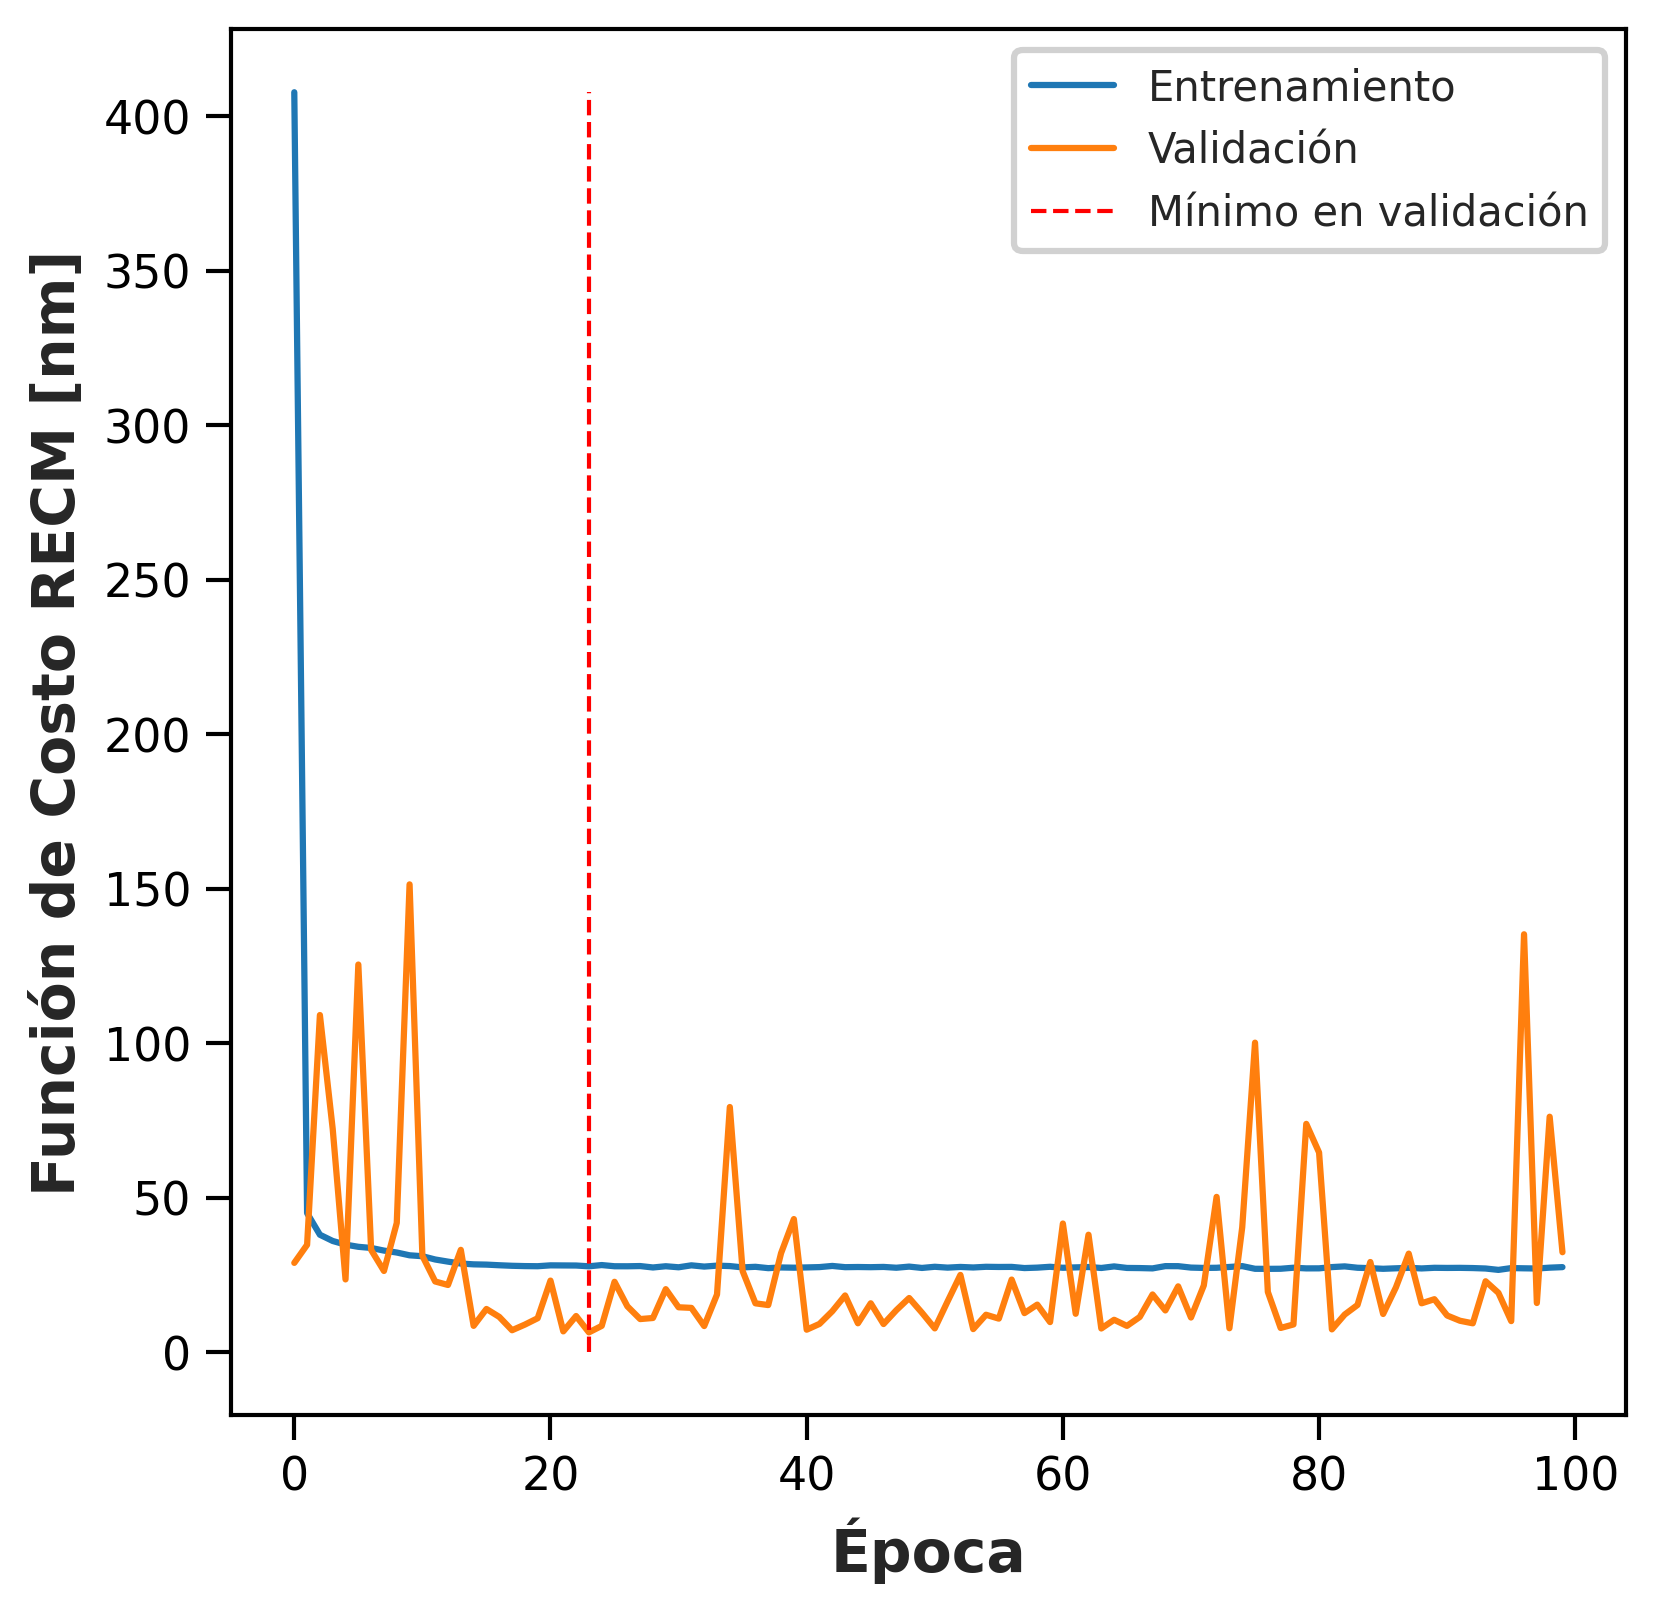

In [7]:
plt.figure(figsize = (6,6))
plt.plot(data['epoch'], data['root_mean_squared_error'], label = 'Entrenamiento')
plt.plot(data['epoch'], data['val_root_mean_squared_error'], label = 'Validación')
plt.vlines( 
    np.argmin(data['val_root_mean_squared_error']), 
    0, 
    np.max(data['root_mean_squared_error']), 
    linestyles= '--', 
    color = 'red', 
    lw = 1, 
    label = 'Mínimo en validación'
)
plt.xlabel('Época')
plt.ylabel('Función de Costo RECM [nm]')
plt.legend()
plt.savefig('./images/rmse.png')
plt.show()

In [8]:
np.argmin(data['val_root_mean_squared_error'])

np.int64(23)

In [9]:
np.argmin(data['val_loss'])

np.int64(21)

In [10]:
np.argmin(data['val_mape'])

np.int64(17)